# **Travaux Pratiques Information Retrieval**

M2 SD/A2IA

### **Students:**

#### *Rodrigo César COELHO FERNANDES*

#### *Vinette Marcy GADEU MONTHE*

In [1]:
from crawler import crawl_wikipedia
from dictionary import DictionaryBuilder
from indexing import DocumentIndexer, QueryIndexer
from similarity import rank_documents
from LangModel import build_language_models, generate_sentence_unigram, generate_sentence_bigram, rank_documents_by_sentence

from io_utils import (
    save_urls, load_urls, urls_exist,
    save_dictionary, load_dictionary, dictionary_exist,
)

import random
import re
from collections import defaultdict, Counter
import math
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

## Crawling

In [2]:
test_url = "https://fr.wikipedia.org/wiki/L%27%C3%89vangile_du_monstre_en_spaghettis_volant"
depth = 2

print("=" * 50)

# ---- URL collection ----
if urls_exist():
    print("Loading URLs from cache...")
    urls = load_urls()
else:
    print("Crawling Wikipedia...")
    urls = crawl_wikipedia(test_url, depth, max_pages=500)
    save_urls(urls)

print(f"Total URLs discovered: {len(urls)}")

Crawling Wikipedia...
Starting BFS crawl from: https://fr.wikipedia.org/wiki/L%27%C3%89vangile_du_monstre_en_spaghettis_volant
Max depth: 2
Max pages: 500
------------------------------------------------------------
[001] Depth 0: https://fr.wikipedia.org/wiki/L%27%C3%89vangile_du_monstre_en_spaghettis_volant
[002] Depth 1: https://fr.wikipedia.org/wiki/Pour_en_finir_avec_Dieu
[003] Depth 1: https://fr.wikipedia.org/wiki/Parodie_de_religion
[004] Depth 1: https://fr.wikipedia.org/wiki/Bobby_Henderson_(pastafarisme)
[005] Depth 1: https://fr.wikipedia.org/wiki/Universit%C3%A9_d%27%C3%89tat_de_Pennsylvanie
[006] Depth 1: https://fr.wikipedia.org/wiki/Intelligent_design_movement
[007] Depth 1: https://fr.wikipedia.org/wiki/Simon_Singh
[008] Depth 1: https://fr.wikipedia.org/wiki/Villard_Books
[009] Depth 1: https://fr.wikipedia.org/wiki/501c
[010] Depth 1: https://fr.wikipedia.org/wiki/Cr%C3%A9ationnisme
[011] Depth 1: https://fr.wikipedia.org/wiki/Satire
[012] Depth 1: https://fr.wikiped

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    With a depth of 2, we obtain more than 1000 urls, but this leads to extremely long execution times in the following tasks, therefore, we limeted the reach to only 500 urls. The unlimited urls and dictionary are available in the "heavy" folder.
  </p>
</div>



In [4]:
for i, url in enumerate(urls):
    print(f"{i:2d}. {url}")

 0. https://fr.wikipedia.org/wiki/International_Standard_Book_Number
 1. https://fr.wikipedia.org/wiki/Bible
 2. https://fr.wikipedia.org/wiki/Diagoras_de_M%C3%A9los
 3. https://fr.wikipedia.org/wiki/Bioterrorisme
 4. https://fr.wikipedia.org/wiki/Acad%C3%A9mie
 5. https://fr.wikipedia.org/wiki/National_Pan-Hellenic_Council
 6. https://fr.wikipedia.org/wiki/%C3%89tats-Unis
 7. https://fr.wikipedia.org/wiki/XVIIIe_si%C3%A8cle
 8. https://fr.wikipedia.org/w/index.php
 9. https://fr.wikipedia.org/wiki/Chevon_Troutman
10. https://fr.wikipedia.org/wiki/Paul_Churchland
11. https://fr.wikipedia.org/wiki/Universit%C3%A9_de_Pittsburgh
12. https://fr.wikipedia.org/wiki/Bradford_(Pennsylvanie)
13. https://fr.wikipedia.org/wiki/Irr%C3%A9ligion_par_pays
14. https://fr.wikipedia.org/wiki/1787
15. https://fr.wikipedia.org/wiki/Mont_Washington
16. https://fr.wikipedia.org/wiki/Titusville_(Pennsylvanie)
17. https://fr.wikipedia.org/wiki/Londres
18. https://fr.wikipedia.org/wiki/Big_East_Conference
19. 

## Dictionnary

In [3]:
if dictionary_exist():
    print("Loading dictionary from cache...")
    dictionary = load_dictionary()
else:
    print("Building dictionary...")
    builder = DictionaryBuilder(urls)
    dictionary = builder.build()
    save_dictionary(dictionary)

print(f"Total unique terms: {len(dictionary)}")

Building dictionary...
Total unique terms: 69522


In [4]:
print("Sample dictionary entries:")
for i, (term, doc_ids) in enumerate(dictionary.items()):
    if i >= 10:
        break
    print(f"{i:2d}. Term: '{term}' - Document IDs: {doc_ids}")

Sample dictionary entries:
 0. Term: 'like' - Document IDs: {'dft': 32, 'idft': 2.7488721956224653}
 1. Term: 'dente' - Document IDs: {'dft': 2, 'idft': 5.521460917862246}
 2. Term: 'annuelle' - Document IDs: {'dft': 28, 'idft': 2.882403588246988}
 3. Term: 'mariages' - Document IDs: {'dft': 19, 'idft': 3.270169119255751}
 4. Term: 'décision' - Document IDs: {'dft': 79, 'idft': 1.8451602459551701}
 5. Term: 'responses' - Document IDs: {'dft': 7, 'idft': 4.268697949366879}
 6. Term: 'cédric' - Document IDs: {'dft': 20, 'idft': 3.2188758248682006}
 7. Term: 'totalité' - Document IDs: {'dft': 125, 'idft': 1.3862943611198906}
 8. Term: 'monde' - Document IDs: {'dft': 285, 'idft': 0.5621189181535412}
 9. Term: 'académie' - Document IDs: {'dft': 84, 'idft': 1.783791299578878}


In [10]:
print("spaghetti = ", dictionary["spaghetti"])
print("monster = ", dictionary["monster"])
print("religion = ", dictionary["religion"])
print("and = ", dictionary["and"])

spaghetti =  {'dft': 12, 'idft': 3.7297014486341915}
monster =  {'dft': 10, 'idft': 3.912023005428146}
religion =  {'dft': 214, 'idft': 0.8486320834003402}
and =  {'dft': 333, 'idft': 0.40646560844174784}


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    As expected, the dictionary has a very high number of terms. And also, the terms with low dtf have a high idtf, because with a low frequency on documents they have a higher discrimination power.
  </p>
  <p>
    Terms directly related to the initial crawl ("spaghetti" and "monster") term have a low term frequency. That shows how our dictionary contains a wide range of topics. A wider term like "religion" brings a lower idft, but not as low as a generic term like "and"
  </p>
</div>

## Document indexing

In [4]:
print("\nIndexing dictionary...")
indexer = DocumentIndexer(dictionary)

doc_url = next(iter(urls))
doc_vectors = indexer.index_document(doc_url)
print("\n Boolean model (first 10 terms):")
for term, value in list(doc_vectors["boolean"].items())[:10]:
    print(term, value)

print("\n wf_idf model (first 10 terms):")
for term, value in list(doc_vectors["wf_idf"].items())[:10]:
    print(term, value)


Indexing dictionary...

 Boolean model (first 10 terms):
rejoint 1
marquée 1
équivalent 1
commentée 1
premiers 1
sont 1
licorne 1
polyèdres 1
lagarde 1
virtualités 1

 wf_idf model (first 10 terms):
rejoint 3.036554268074246
marquée 2.8473122684357177
équivalent 2.631089159966082
commentée 4.605170185988092
premiers 3.3567042942777805
sont 2.2886597587095343
licorne 4.8283137373023015
polyèdres 10.522246180128537
lagarde 10.522246180128537
virtualités 6.214608098422191


Percentage of terms with boolean value 1: 2.18%


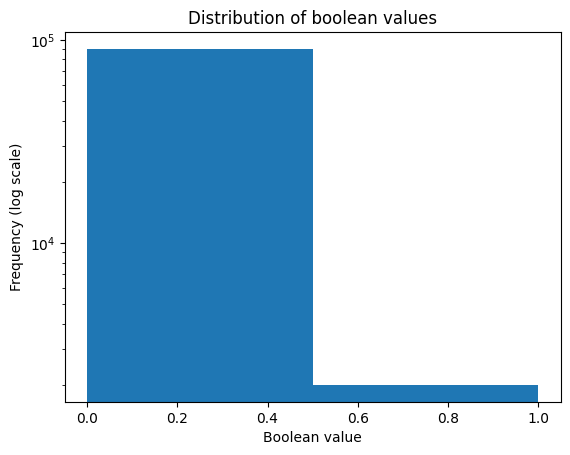

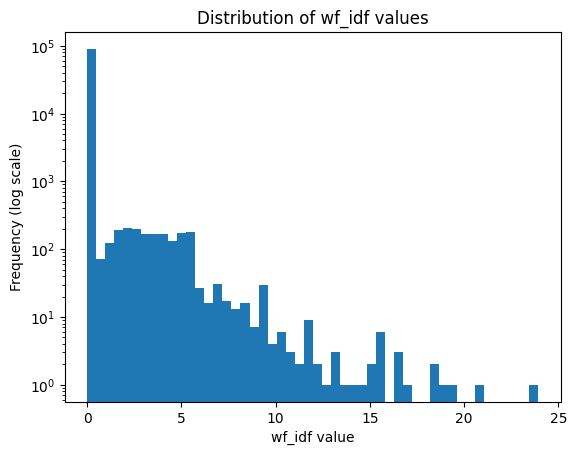

In [12]:
# Plot boolean
boolean_idf_values = list(doc_vectors["boolean"].values())
sum_boolean_values = sum(boolean_idf_values)
total_terms = len(boolean_idf_values)
perc_one_boolean = (sum_boolean_values / total_terms) * 100
print(f"Percentage of terms with boolean value 1: {perc_one_boolean:.2f}%")

plt.hist(boolean_idf_values, bins=2, log=True)
plt.title("Distribution of boolean values")
plt.xlabel("Boolean value")
plt.ylabel("Frequency (log scale)")
plt.show()


# Plot wf_idf
wf_idf_values = list(doc_vectors["wf_idf"].values())
plt.hist(wf_idf_values, bins=50, log=True)
plt.title("Distribution of wf_idf values")
plt.xlabel("wf_idf value")
plt.ylabel("Frequency (log scale)")

plt.show()


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Here we index a single document to analyse its results. The boolean indexing offers a very simplistic approach, showing that only 2,18% of our dictionary is present in the document.
  </p>
  <p>
    In the other hand, the weighted indexing has a good balance of giving a low weight to many documents and higher weights to a gradually smaller number of terms.
  </p>
</div>



## Querying


Query: "religion satire"

Top 10 documents using boolean:
 1. https://fr.wikipedia.org/wiki/L%27%C3%89vangile_du_monstre_en_spaghettis_volant  (score=0.0875)
 2. https://fr.wikipedia.org/wiki/Parodie_de_religion  (score=0.0724)
 3. https://fr.wikipedia.org/wiki/William_Dembski  (score=0.0714)
 4. https://fr.wikipedia.org/wiki/Recovering_from_religion  (score=0.0674)
 5. https://fr.wikipedia.org/wiki/Post-th%C3%A9isme  (score=0.0654)
 6. https://fr.wikipedia.org/wiki/De_la_suffisance_de_la_religion_naturelle  (score=0.0623)
 7. https://fr.wikipedia.org/wiki/Guerre_de_religion  (score=0.0602)
 8. https://fr.wikipedia.org/wiki/Argument_t%C3%A9l%C3%A9ologique  (score=0.0572)
 9. https://fr.wikipedia.org/wiki/Nouveau_paradigme  (score=0.0552)
10. https://fr.wikipedia.org/wiki/Irr%C3%A9ligion_par_pays  (score=0.0546)


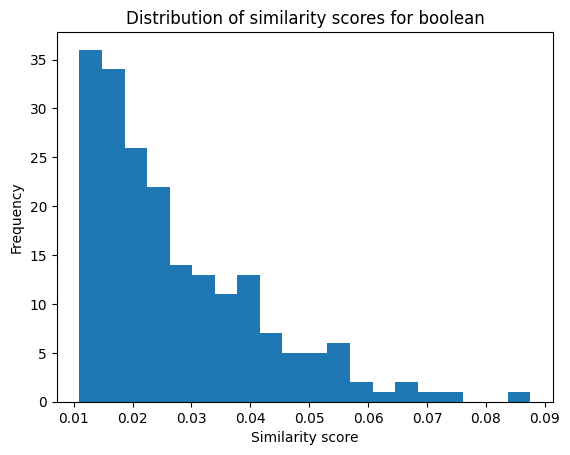


Top 10 documents using tf:
 1. https://fr.wikipedia.org/wiki/Guerre_de_religion  (score=0.3600)
 2. https://fr.wikipedia.org/wiki/De_la_suffisance_de_la_religion_naturelle  (score=0.2415)
 3. https://fr.wikipedia.org/wiki/Satire  (score=0.2381)
 4. https://fr.wikipedia.org/wiki/Irr%C3%A9ligion_en_France  (score=0.2356)
 5. https://fr.wikipedia.org/wiki/Religion  (score=0.2231)
 6. https://fr.wikipedia.org/wiki/Religion_ath%C3%A9e  (score=0.2190)
 7. https://fr.wikipedia.org/wiki/Antireligion  (score=0.2147)
 8. https://fr.wikipedia.org/wiki/Recovering_from_religion  (score=0.2065)
 9. https://fr.wikipedia.org/wiki/Dieu_n%27est_pas_grand  (score=0.1893)
10. https://fr.wikipedia.org/wiki/Parodie_de_religion  (score=0.1807)


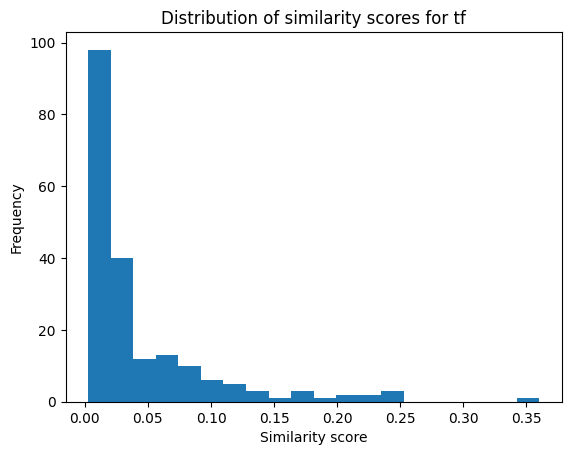


Top 10 documents using wf:
 1. https://fr.wikipedia.org/wiki/Guerre_de_religion  (score=0.1527)
 2. https://fr.wikipedia.org/wiki/De_la_suffisance_de_la_religion_naturelle  (score=0.1406)
 3. https://fr.wikipedia.org/wiki/Recovering_from_religion  (score=0.1399)
 4. https://fr.wikipedia.org/wiki/Parodie_de_religion  (score=0.1181)
 5. https://fr.wikipedia.org/wiki/Dieu_n%27est_pas_grand  (score=0.1165)
 6. https://fr.wikipedia.org/wiki/Irr%C3%A9ligion_en_France  (score=0.1079)
 7. https://fr.wikipedia.org/wiki/Religion_ath%C3%A9e  (score=0.1078)
 8. https://fr.wikipedia.org/wiki/Licorne_rose_invisible  (score=0.1041)
 9. https://fr.wikipedia.org/wiki/Antireligion  (score=0.0995)
10. https://fr.wikipedia.org/wiki/Irr%C3%A9ligion_par_pays  (score=0.0974)


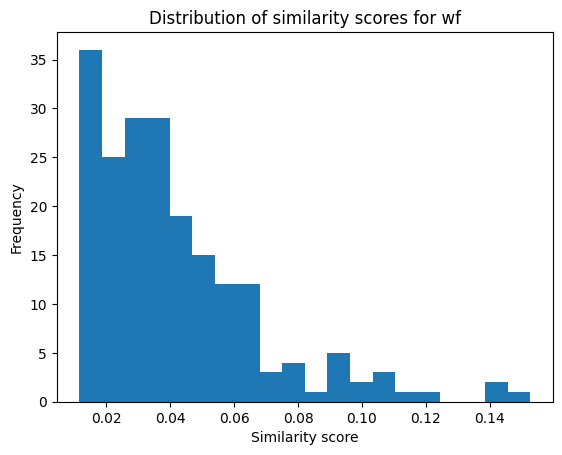


Top 10 documents using tf_idf:
 1. https://fr.wikipedia.org/wiki/Satire  (score=0.6357)
 2. https://fr.wikipedia.org/wiki/Religion  (score=0.0972)
 3. https://fr.wikipedia.org/wiki/Parodie_de_religion  (score=0.0679)
 4. https://fr.wikipedia.org/wiki/Guerre_de_religion  (score=0.0657)
 5. https://fr.wikipedia.org/wiki/Licorne_rose_invisible  (score=0.0646)
 6. https://fr.wikipedia.org/wiki/Critique_de_la_religion  (score=0.0570)
 7. https://fr.wikipedia.org/wiki/Irr%C3%A9ligion_en_France  (score=0.0531)
 8. https://fr.wikipedia.org/wiki/Religion_ath%C3%A9e  (score=0.0478)
 9. https://fr.wikipedia.org/wiki/L%27%C3%89vangile_du_monstre_en_spaghettis_volant  (score=0.0404)
10. https://fr.wikipedia.org/wiki/De_la_suffisance_de_la_religion_naturelle  (score=0.0377)


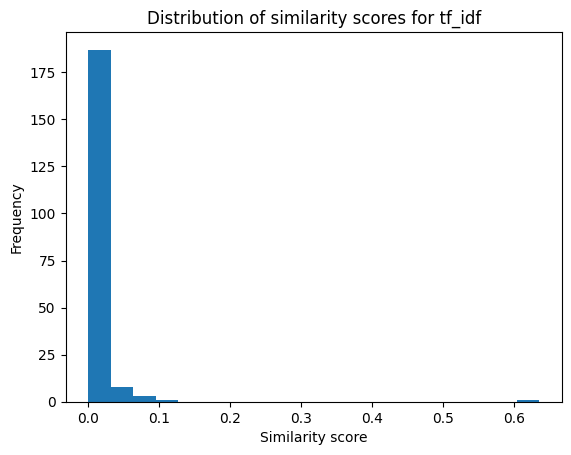


Top 10 documents using wf_idf:
 1. https://fr.wikipedia.org/wiki/Satire  (score=0.1386)
 2. https://fr.wikipedia.org/wiki/Licorne_rose_invisible  (score=0.0807)
 3. https://fr.wikipedia.org/wiki/L%27%C3%89vangile_du_monstre_en_spaghettis_volant  (score=0.0651)
 4. https://fr.wikipedia.org/wiki/Parodie_de_religion  (score=0.0620)
 5. https://fr.wikipedia.org/wiki/Monty_Python_:_La_Vie_de_Brian  (score=0.0422)
 6. https://fr.wikipedia.org/wiki/Pastafarisme  (score=0.0397)
 7. https://fr.wikipedia.org/wiki/Flying_Spaghetti_Monster  (score=0.0397)
 8. https://fr.wikipedia.org/wiki/Fant%C3%B4me_de_Cock_Lane  (score=0.0278)
 9. https://fr.wikipedia.org/wiki/Denis_Diderot  (score=0.0265)
10. https://fr.wikipedia.org/wiki/Friedrich_Nietzsche  (score=0.0249)


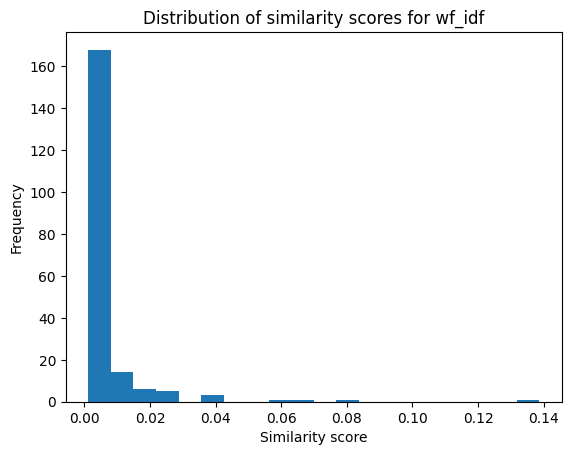

In [13]:
doc_vectors = {}
for url in urls:
    doc_vectors[url] = indexer.index_document(url)

queries = [
    "religion satire",
    # "intelligent design",
    # "scientific criticism of religion"
]

query_indexer = QueryIndexer(dictionary)

schemes = ["boolean", "tf", "wf", "tf_idf", "wf_idf"]

for query in queries:
    print(f"\nQuery: \"{query}\"")
    query_vec = query_indexer.index_query(query)

    for scheme in schemes:
        print(f"\nTop 10 documents using {scheme}:")
        top_docs = rank_documents(query_vec, doc_vectors, scheme, top_k=200)

        for rank, (url, score) in enumerate(top_docs, start=1):
            print(f"{rank:2d}. {url}  (score={score:.4f})")
            if rank == 10:
                break

        plt.hist([score for url, score in top_docs], bins=20, log=False)
        plt.title(f"Distribution of similarity scores for {scheme}")
        plt.xlabel("Similarity score")
        plt.ylabel("Frequency")
        plt.show()

Using a generic query, we can see that tf_idf and wf_idf give a strong preference for a single document, gererating a range of scores whithout any documents. The other similarity methods fill better the score range with a gradually decreasing number of documents with higher scores.

The highest scoring document is not constant over all methods, they do not agree. But the top 10 documents seem to be the same, but with shifting positions.


Query: "spaghetti monster"

Top 10 documents using boolean:
 1. https://fr.wikipedia.org/wiki/Bobby_Henderson_(pastafarisme)  (score=0.1204)
 2. https://fr.wikipedia.org/wiki/Chute_intelligente  (score=0.0925)
 3. https://fr.wikipedia.org/wiki/L%27%C3%89vangile_du_monstre_en_spaghettis_volant  (score=0.0875)
 4. https://fr.wikipedia.org/wiki/Parodie_de_religion  (score=0.0724)
 5. https://fr.wikipedia.org/wiki/Benjamin_Radford  (score=0.0589)
 6. https://fr.wikipedia.org/wiki/Licorne_rose_invisible  (score=0.0535)
 7. https://fr.wikipedia.org/wiki/Joe_Nickell  (score=0.0350)
 8. https://fr.wikipedia.org/wiki/Pastafarisme  (score=0.0316)
 9. https://fr.wikipedia.org/wiki/Flying_Spaghetti_Monster  (score=0.0316)
10. https://fr.wikipedia.org/wiki/Imp%C3%B4t_philosophiquement_d%C3%A9dicac%C3%A9  (score=0.0295)


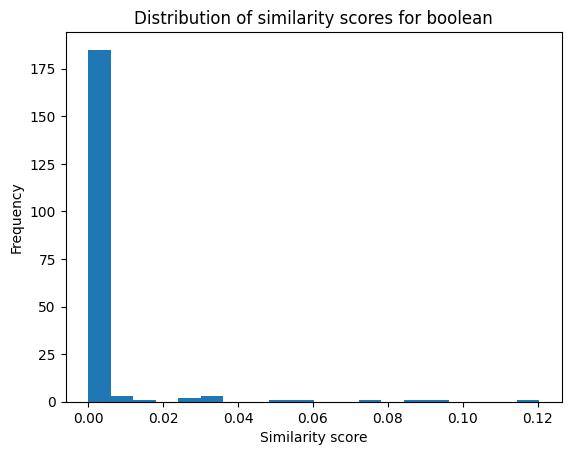


Top 10 documents using tf:
 1. https://fr.wikipedia.org/wiki/Pastafarisme  (score=0.3185)
 2. https://fr.wikipedia.org/wiki/Flying_Spaghetti_Monster  (score=0.3185)
 3. https://fr.wikipedia.org/wiki/L%27%C3%89vangile_du_monstre_en_spaghettis_volant  (score=0.2314)
 4. https://fr.wikipedia.org/wiki/Bobby_Henderson_(pastafarisme)  (score=0.1659)
 5. https://fr.wikipedia.org/wiki/Monstre_du_loch_Ness  (score=0.0705)
 6. https://fr.wikipedia.org/wiki/Benjamin_Radford  (score=0.0648)
 7. https://fr.wikipedia.org/wiki/Chute_intelligente  (score=0.0404)
 8. https://fr.wikipedia.org/wiki/Parodie_de_religion  (score=0.0301)
 9. https://fr.wikipedia.org/wiki/Licorne_rose_invisible  (score=0.0191)
10. https://fr.wikipedia.org/wiki/Joe_Nickell  (score=0.0122)


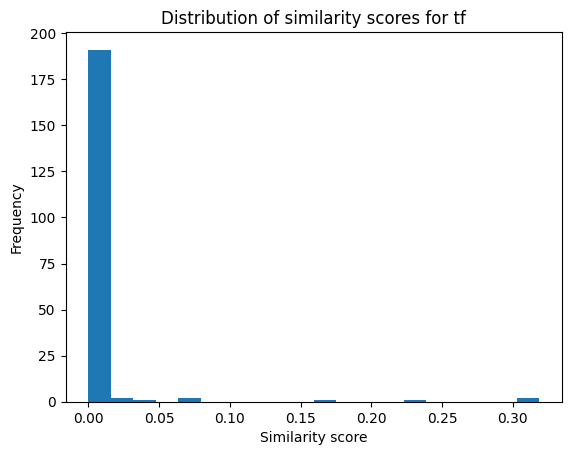


Top 10 documents using wf:
 1. https://fr.wikipedia.org/wiki/L%27%C3%89vangile_du_monstre_en_spaghettis_volant  (score=0.1751)
 2. https://fr.wikipedia.org/wiki/Bobby_Henderson_(pastafarisme)  (score=0.1741)
 3. https://fr.wikipedia.org/wiki/Pastafarisme  (score=0.1035)
 4. https://fr.wikipedia.org/wiki/Flying_Spaghetti_Monster  (score=0.1035)
 5. https://fr.wikipedia.org/wiki/Benjamin_Radford  (score=0.0783)
 6. https://fr.wikipedia.org/wiki/Chute_intelligente  (score=0.0684)
 7. https://fr.wikipedia.org/wiki/Parodie_de_religion  (score=0.0537)
 8. https://fr.wikipedia.org/wiki/Licorne_rose_invisible  (score=0.0485)
 9. https://fr.wikipedia.org/wiki/Monstre_du_loch_Ness  (score=0.0459)
10. https://fr.wikipedia.org/wiki/Joe_Nickell  (score=0.0254)


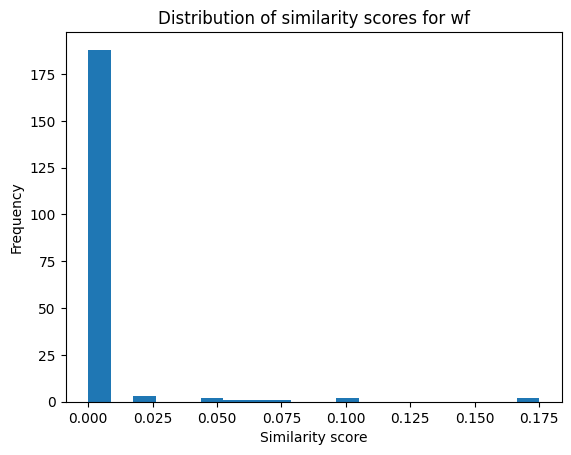


Top 10 documents using tf_idf:
 1. https://fr.wikipedia.org/wiki/Pastafarisme  (score=0.5814)
 2. https://fr.wikipedia.org/wiki/Flying_Spaghetti_Monster  (score=0.5814)
 3. https://fr.wikipedia.org/wiki/L%27%C3%89vangile_du_monstre_en_spaghettis_volant  (score=0.3599)
 4. https://fr.wikipedia.org/wiki/Bobby_Henderson_(pastafarisme)  (score=0.3109)
 5. https://fr.wikipedia.org/wiki/Monstre_du_loch_Ness  (score=0.1035)
 6. https://fr.wikipedia.org/wiki/Benjamin_Radford  (score=0.0885)
 7. https://fr.wikipedia.org/wiki/Chute_intelligente  (score=0.0786)
 8. https://fr.wikipedia.org/wiki/Parodie_de_religion  (score=0.0655)
 9. https://fr.wikipedia.org/wiki/Licorne_rose_invisible  (score=0.0326)
10. https://fr.wikipedia.org/wiki/Joe_Nickell  (score=0.0180)


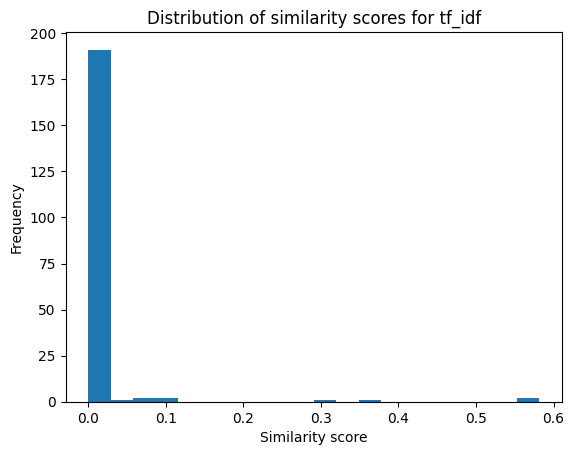


Top 10 documents using wf_idf:
 1. https://fr.wikipedia.org/wiki/Bobby_Henderson_(pastafarisme)  (score=0.3093)
 2. https://fr.wikipedia.org/wiki/L%27%C3%89vangile_du_monstre_en_spaghettis_volant  (score=0.2701)
 3. https://fr.wikipedia.org/wiki/Pastafarisme  (score=0.1385)
 4. https://fr.wikipedia.org/wiki/Flying_Spaghetti_Monster  (score=0.1385)
 5. https://fr.wikipedia.org/wiki/Benjamin_Radford  (score=0.1086)
 6. https://fr.wikipedia.org/wiki/Chute_intelligente  (score=0.1057)
 7. https://fr.wikipedia.org/wiki/Parodie_de_religion  (score=0.0821)
 8. https://fr.wikipedia.org/wiki/Licorne_rose_invisible  (score=0.0658)
 9. https://fr.wikipedia.org/wiki/Monstre_du_loch_Ness  (score=0.0586)
10. https://fr.wikipedia.org/wiki/Joe_Nickell  (score=0.0337)


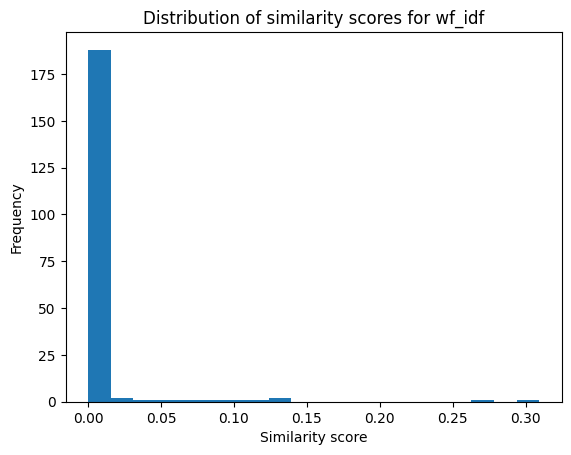

In [16]:
queries = [
    "spaghetti monster",
]

for query in queries:
    print(f"\nQuery: \"{query}\"")
    query_vec = query_indexer.index_query(query)

    for scheme in schemes:
        print(f"\nTop 10 documents using {scheme}:")
        top_docs = rank_documents(query_vec, doc_vectors, scheme, top_k=200)

        for rank, (url, score) in enumerate(top_docs, start=1):
            print(f"{rank:2d}. {url}  (score={score:.4f})")
            if rank == 10:
                break

        plt.hist([score for url, score in top_docs], bins=20, log=False)
        plt.title(f"Distribution of similarity scores for {scheme}")
        plt.xlabel("Similarity score")
        plt.ylabel("Frequency")
        plt.show()

Using a more focused query, all methods behave similarly by atributing a high score to a very few number of documents. But once again, there is no agreement on the best document alghtough the top documents seem to be the same but switching the positions depending on the method.

## Language Model

In [9]:
# ---- Build models ----
unigram_probs, bigram_probs, doc_models, V = build_language_models(urls, indexer)

print(f"\nVocabulary size: {len(unigram_probs)}")

# ---- Generate sentences ----
print("\nGenerated sentences (Unigram model):")
for _ in range(3):
    print("-", generate_sentence_unigram(unigram_probs, length=12))

print("\nGenerated sentences (Bigram model):")
for _ in range(3):
    print("-", generate_sentence_bigram(unigram_probs, bigram_probs, length=12))


Vocabulary size: 100067

Generated sentences (Unigram model):
- 79 le monde le fondateur fourgous dominique profondément dieu de des mínus
- production favorables que monde playboy l sexuelles amazon partir thomas journal vivraient
- du boston modifier 1940 classe enfants bénéficier née la of qu un

Generated sentences (Bigram model):
- notre décision ses manifestations individuelles la suffisance de christian garcin et l
- des émissions de jean baptiste vanzini laïcité j gagnon john blackwood and
- fabien girandola psychologie de l exemple au front national de son comportement


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can see that the Unigram model (P(t)) generate a sequence of random independent words that rarely touch the initial theme of the scrapper, that is, words that are rarely meanful, it tends to generate random common adjectves, verbs and nouns.
  </p>
  <p>
    The Bigram model P(ti|tj) generate sentences that continue to have no logical meaning, but have more coherence. This happens because each word depends only on the previous one, so there is not a long range structure to enhance the model capability.
  </p>
</div>

In [7]:
# doc_models, V = build_document_language_models(urls)

test_sentences = [
    "Religion et science",
    "Monstre de spaghetti volant",
]

for sentence in test_sentences:
    print(f"\nSentence: \"{sentence}\"")

    ranked_docs = rank_documents_by_sentence(sentence, doc_models, V)

    print("\nTop 5 documents:")
    for i, (url, score) in enumerate(ranked_docs[:5], 1):
        print(f"{i}. {url} (log P={score:.4f})")


Sentence: "Religion et science"

Top 5 documents:
1. https://fr.wikipedia.org/wiki/Sciences (log P=-19.6622)
2. https://fr.wikipedia.org/wiki/Religion (log P=-19.9603)
3. https://fr.wikipedia.org/wiki/Relation_entre_science_et_religion (log P=-20.8019)
4. https://fr.wikipedia.org/wiki/Sigmund_Freud (log P=-21.6685)
5. https://fr.wikipedia.org/wiki/Ath%C3%A9isme (log P=-22.2048)

Sentence: "Monstre de spaghetti volant"

Top 5 documents:
1. https://fr.wikipedia.org/wiki/Pastafarisme (log P=-27.9187)
2. https://fr.wikipedia.org/wiki/Flying_Spaghetti_Monster (log P=-27.9187)
3. https://fr.wikipedia.org/wiki/Monstre_en_spaghetti_volant (log P=-27.9187)
4. https://fr.wikipedia.org/wiki/L%27%C3%89vangile_du_monstre_en_spaghettis_volant (log P=-36.5087)
5. https://fr.wikipedia.org/wiki/Monstre_du_loch_Ness (log P=-36.6033)


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    For the first query, a more generic one, the highest-ranked documents correspond to broad conceptual topics, indicating that the probability estimates favor documents whose vocabularies strongly overlap with the query terms.
  </p>
  <p>
    For the second query, the identical log-probability values observed for the first three documents indicate that these pages likely share very similar term distributions with respect to the query vocabulary, reflecting strong lexical alignment.
  </p>
</div>

# Document classification

In [ ]:
df = pd.read_csv("data/LeMonde2003_9classes.csv.gz", compression='gzip')

In [ ]:
print(df.describe())

df.head(10)


=== DESCRIBE ===
                                                     text category
count                                               30165    30165
unique                                              30163        7
top     alcatel space filiale de fabrication de satell...      INT
freq                                                    2     7328


,text,category
0,a la boutique du fulham fc nichée au dernier é...,SPO
1,pour la plupart de ceux qui n'y vivent pas la ...,ART
2,la perspective d'une enquête judiciaire sur la...,FRA
3,le tribunal administratif de limoges a annulé ...,SOC
4,des avions américains et britanniques ont bomb...,INT
5,nous sommes des professeurs de droit internati...,INT
6,la cour d'appel de nancy a refusé lundi 17 mar...,FRA
7,objectif matignon gêné sur le plan internation...,FRA
8,pour la première fois dans l'histoire de la ve...,FRA
9,des dizaines de milliers de personnes fuyant l...,INT


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Simple dataset structure with the text to be used as the only feature and the category as the label to be predicted.
  </p>
</div>

In [ ]:
# data prep
X = df["text"]
y = df["category"]


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 21115
Validation size: 4525
Test size: 4525


In [ ]:
# models + features
models = {
    "NB + Count": Pipeline([
        ("vect", CountVectorizer()),
        ("clf", MultinomialNB())
    ]),

    "NB + TFIDF": Pipeline([
        ("vect", TfidfVectorizer()),
        ("clf", MultinomialNB())
    ]),

    "LogReg + TFIDF": Pipeline([
        ("vect", TfidfVectorizer(max_features=20000)),
        ("clf", LogisticRegression(max_iter=1000))
    ]),

    "SVM + TFIDF": Pipeline([
        ("vect", TfidfVectorizer(max_features=20000)),
        ("clf", LinearSVC())
    ])
}


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We compare different combinations of the feature sets CountVectorizer and TfidVectorizer with the models Naive Bayes, Logistic Regrassion and SVM.
  </p>
</div>

In [ ]:
# Model selection
best_model = None
best_score = 0

print("\n=== Validation Results ===")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)

    print(f"{name}: {acc:.4f}")

    if acc > best_score:
        best_score = acc
        best_model = model
        best_name = name

print(f"\nBest model: {best_name} (Accuracy = {best_score:.4f})")


=== Validation Results ===
NB + Count: 0.8206
NB + TFIDF: 0.6294
LogReg + TFIDF: 0.8402
SVM + TFIDF: 0.8508

Best model: SVM + TFIDF (Accuracy = 0.8508)


<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The SVM+Tfidf achieved the highest classification accuracy, Naive Bayes with TF-IDF features obtained by far the lowest validation accuracy, indicating that this combination was less suitable for the dataset.
  </p>
</div>

In [ ]:
# test
y_test_pred = best_model.predict(X_test)

print("\n=== Test Performance ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))


=== Test Performance ===
Accuracy: 0.845524861878453

Classification Report:

              precision    recall  f1-score   support

         ART       0.91      0.93      0.92       683
         ENT       0.88      0.92      0.90       938
         FRA       0.73      0.73      0.73       542
         INT       0.87      0.93      0.90      1099
         SOC       0.76      0.79      0.77       564
         SPO       0.94      0.95      0.95       391
         UNE       0.59      0.28      0.38       308

    accuracy                           0.85      4525
   macro avg       0.81      0.79      0.79      4525
weighted avg       0.84      0.85      0.84      4525



<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The test results confirm that the selected model maintains stable performance, achieving an overall accuracy of approximately 0.85. The classification report indicates high precision and recall for categories such as SPO, ART, and ENT, suggesting that these classes are well represented and easier to distinguish.
  </p>
</div>